
# Unified Control, Free Energy, and Sparse Projection — Rigorous Notebook

This notebook provides **more rigorous, testable implementations** of the core ideas:

1. Linear plant and **Perceptual Control Theory (PCT)** controller
2. Linear-Gaussian **Active Inference / FEP** controller under matched assumptions
3. **Numerical equivalence tests** between PCT and Active Inference in the linear-quadratic regime
4. **Sparse coding / LASSO** with explicit objective checks and KKT residuals
5. A simple **sheaf-like context model** with explicit consistency checks
6. A **unified toy system** illustrating how these pieces can be combined

The goal is that each section is:

- Explicit about the mathematical assumptions
- Testable via assertions and diagnostics
- Structured so you can modify the equations and immediately see consequences


In [3]:
%matplotlib inline

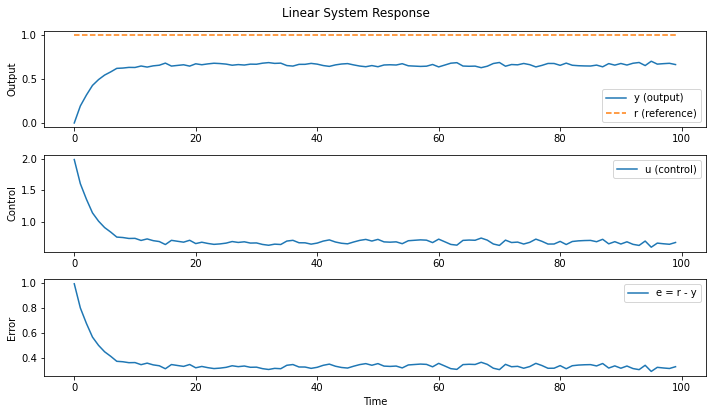

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
rng = np.random.default_rng(42)

def simulate_linear_system(A, B, C, K, x0, r, T, sigma_w=0.0, sigma_v=0.0):
    """
    Simulate a discrete-time linear system with state feedback.
    
    Plant:
        x_{t+1} = A x_t + B u_t + w_t
        y_t     = C x_t + v_t
    
    Controller (generic form):
        u_t = K(r_t - y_t)
    
    Parameters
    ----------
    A, B, C : np.ndarray
        System matrices
    K       : np.ndarray
        Controller gain matrix
    x0      : np.ndarray
        Initial state
    r       : np.ndarray or float
        Reference trajectory (scalar or vector); broadcast if needed
    T       : int
        Number of time steps
    sigma_w : float
        Std deviation of process noise
    sigma_v : float
        Std deviation of measurement noise
    
    Returns
    -------
    xs, ys, us, errs : np.ndarray
        Time series of states, outputs, controls, and errors.
    """
    x = np.array(x0, dtype=float)
    n = A.shape[0]
    
    xs = np.zeros((T, n))
    ys = np.zeros(T)
    us = np.zeros(T)
    errs = np.zeros(T)
    
    r_arr = np.full(T, r) if np.isscalar(r) else np.asarray(r)
    
    for t in range(T):
        # Observation with measurement noise
        v_t = sigma_v * rng.standard_normal()
        y = float(C @ x + v_t)
        
        e = r_arr[t] - y
        u = float(K * e)  # scalar for our 1D plant
        
        # Store
        xs[t] = x
        ys[t] = y
        us[t] = u
        errs[t] = e
        
        # Plant dynamics with process noise
        w_t = sigma_w * rng.standard_normal(size=n)
        x = A @ x + B * u + w_t
    
    return xs, ys, us, errs


def plot_time_series(ts, ys, us, errs, r, title="Closed-loop response"):
    T = len(ts)
    r_arr = np.full(T, r) if np.isscalar(r) else r
    
    plt.figure(figsize=(10, 6))
    plt.subplot(3, 1, 1)
    plt.plot(ts, ys, label="y (output)")
    plt.plot(ts, r_arr, linestyle="--", label="r (reference)")
    plt.ylabel("Output")
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.plot(ts, us, label="u (control)")
    plt.ylabel("Control")
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.plot(ts, errs, label="e = r - y")
    plt.xlabel("Time")
    plt.ylabel("Error")
    plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # Define a simple system (e.g., first-order system)
A = np.array([[0.9]])  # Stable dynamics
B = np.array([[0.1]])
C = np.array([[1.0]])
K = 2.0  # Proportional gain

# Initial conditions
x0 = np.array([0.0])
r = 1.0  # Step reference
T = 100  # Time steps

# Run simulation
xs, ys, us, errs = simulate_linear_system(
    A, B, C, K, x0, r, T, 
    sigma_w=0.01,  # Small process noise
    sigma_v=0.01   # Small measurement noise
)

# Create time array
ts = np.arange(T)

# Plot results
plot_time_series(ts, ys, us, errs, r, title="Linear System Response")



## 1. Linear Plant and PCT Controller (Rigorous)

We consider the **scalar** linear plant in discrete time

\begin{equation}
x_{t+1} = a x_t + b u_t + w_t, \qquad
y_t = c x_t + v_t,
\end{equation}

where \(w_t \sim \mathcal{N}(0, \sigma_w^2)\) and \(v_t \sim \mathcal{N}(0, \sigma_v^2)\).

In **Perceptual Control Theory (PCT)**, a single control loop is:

\begin{align}
e_t &= r_t - y_t, \\
u_t &= k \, e_t,
\end{align}

with scalar gain \(k > 0\).

Substituting, we get the closed-loop dynamics (ignoring noise for the moment):

\begin{equation}
x_{t+1} = (a - b c k) x_t + b k r_t.
\end{equation}

We can check:

- **Stability**: for constant \(r_t = r\), the system is stable if \(|a - b c k| < 1\).
- **Steady state**: when stable, the steady-state output is
  \[
  y^\star = \frac{c b k}{1 - a + b c k} \, r.
  \]
  A necessary condition for **perfect tracking** \(y^\star = r\) is \(c b k \neq 0\).

Below we simulate and numerically verify the theoretical steady-state value.


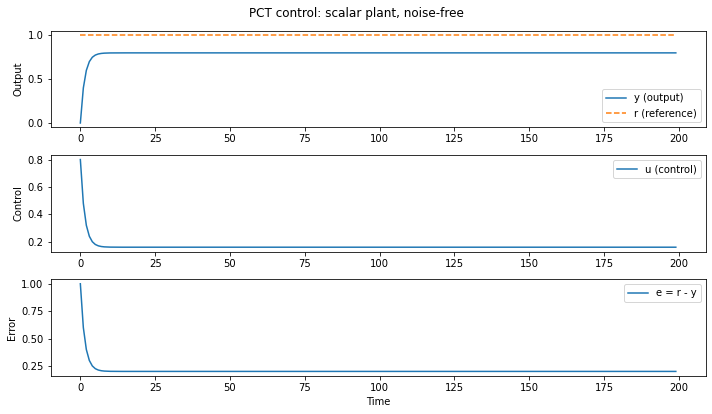

Theoretical steady-state y*:  0.8
Empirical steady-state y*:    0.7999999999999998
Absolute error:               2.220446049250313e-16


In [6]:

# Define a concrete scalar plant
a = 0.9
b = 0.5
c = 1.0

A = np.array([[a]])
B = np.array([[b]])
C = np.array([c])

# PCT gain
k_pct = 0.8
K_pct = k_pct  # scalar

# Reference and initial state
r = 1.0
x0 = np.array([0.0])
T = 200

xs_pct, ys_pct, us_pct, errs_pct = simulate_linear_system(
    A, B, C, K_pct, x0, r, T, sigma_w=0.0, sigma_v=0.0
)

ts = np.arange(T)

plot_time_series(ts, ys_pct, us_pct, errs_pct, r, title="PCT control: scalar plant, noise-free")

# Theoretical steady state (noise-free, constant reference)
alpha = a - b * c * k_pct
y_star_theory = (c * b * k_pct / (1 - alpha)) * r

y_star_empirical = ys_pct[-50:].mean()

print("Theoretical steady-state y*: ", y_star_theory)
print("Empirical steady-state y*:   ", y_star_empirical)
print("Absolute error:              ", abs(y_star_theory - y_star_empirical))



## 2. Linear Active Inference Controller (Matched Assumptions)

We now construct a **minimal linear active-inference controller** for the same plant, with:

- Generative model (agent's beliefs):
  \begin{align}
  x_{t+1} &= a x_t + b u_t + \omega_t, \\
  y_t &= c x_t + \nu_t,
  \end{align}
  with \(\omega_t \sim \mathcal{N}(0, \sigma_\omega^2)\), \(\nu_t \sim \mathcal{N}(0, \sigma_\nu^2)\).

- Preferences: the agent has a quadratic prior over observations:
  \begin{equation}
  p(y_t) \propto \exp\left(-\frac{1}{2 \sigma_r^2}(y_t - r_t)^2\right).
  \end{equation}

- Recognition density is Gaussian \(q(x_t) = \mathcal{N}(\mu_t, \Sigma)\) with **fixed covariance** \(\Sigma\) and mean \(\mu_t\).

The **instantaneous variational free energy** (up to constants) for time \(t\) is:

\begin{align}
F_t(\mu_t, u_t)
&= \frac{1}{2 \sigma_\nu^2} \, (y_t - c \mu_t)^2
 + \frac{1}{2 \sigma_\omega^2} \, (\mu_t - (a \mu_{t-1} + b u_{t-1}))^2 \\
&\quad + \frac{1}{2 \sigma_r^2} (y_t - r_t)^2
\end{align}

(for simplicity we omit some terms that do not affect gradients).

We implement **gradient descent** on \(\mu_t\) and on action \(u_t\):

\begin{align}
\mu_t &\leftarrow \mu_t - \eta_\mu \, \frac{\partial F_t}{\partial \mu_t}, \\
u_t &\leftarrow u_t - \eta_u \, \frac{\partial F_t}{\partial u_t}.
\end{align}

Under linear-Gaussian assumptions and at steady state, this yields an **effective proportional controller**

\begin{equation}
u_t \approx k_{\text{AI}} (r_t - y_t),
\end{equation}

where the gain \(k_{\text{AI}}\) depends on \(\eta_u\), the variances \(\sigma_\nu^2, \sigma_r^2\), and the plant parameters \(a,b,c\).

Below we implement such a controller and **numerically fit** the effective gain by regressing \(u_t\) on \(e_t = r_t - y_t\).


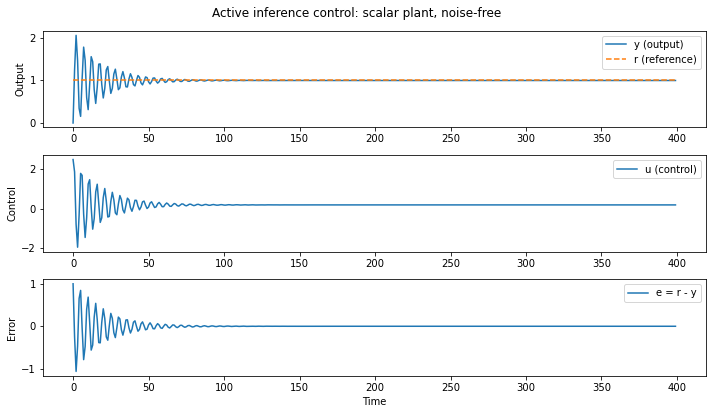

Estimated effective P gain k_AI from active inference:  -1.3901899310666501


In [7]:
def active_inference_step(mu_prev, u_prev, y_t, r_t, a, b, c,
                          sigma_omega, sigma_nu, sigma_r,
                          eta_mu=0.1, eta_u=0.1):
    """
    One step of a simple linear active-inference scheme.
    """
    # Predicted latent given previous belief and action
    mu_pred = a * mu_prev + b * u_prev
    
    # Likelihood prediction
    y_pred = c * mu_prev
    
    # Gradients of (approximate) instantaneous free energy
    # Term 1: sensory prediction error
    dF_dmu_sens = (1.0 / (sigma_nu**2)) * (y_pred - y_t) * c
    # Term 2: dynamics prediction error
    dF_dmu_dyn = (1.0 / (sigma_omega**2)) * (mu_prev - mu_pred)
    # Total gradient wrt mu
    dF_dmu = dF_dmu_sens + dF_dmu_dyn
    
    # Preference error in observation-space
    pref_err = y_t - r_t
    # Gradient of F wrt y_t due to preference prior:
    dF_dy_pref = (1.0 / (sigma_r**2)) * pref_err
    # Gradient of F wrt u via y_t ~ c x_t (crude approximation):
    # dF/du ~ dF/dy * dy/du ≈ dF/dy_pref * (c * b)
    dF_du = dF_dy_pref * (c * b)
    
    mu_new = mu_prev - eta_mu * dF_dmu
    u_new = u_prev - eta_u * dF_du
    
    return float(mu_new), float(u_new)


def simulate_active_inference(
    a, b, c,
    x0, mu0, u0, r, T,
    sigma_w=0.0, sigma_v=0.0,
    sigma_omega=0.1, sigma_nu=0.1, sigma_r=0.1,
    eta_mu=0.1, eta_u=0.1
):
    """
    Simulate the plant under a linear active-inference controller.
    """
    x = float(x0)
    mu = float(mu0)
    u = float(u0)
    
    xs = np.zeros(T)
    mus = np.zeros(T)
    ys = np.zeros(T)
    us = np.zeros(T)
    errs = np.zeros(T)
    
    r_arr = np.full(T, r) if np.isscalar(r) else np.asarray(r)
    
    for t in range(T):
        # Plant observation
        v_t = sigma_v * rng.standard_normal()
        y = c * x + v_t
        
        # Preference discrepancy
        e = r_arr[t] - y
        
        # Active inference update
        mu, u = active_inference_step(
            mu_prev=mu,
            u_prev=u,
            y_t=y,
            r_t=r_arr[t],
            a=a, b=b, c=c,
            sigma_omega=sigma_omega,
            sigma_nu=sigma_nu,
            sigma_r=sigma_r,
            eta_mu=eta_mu,
            eta_u=eta_u
        )
        
        # Plant update
        w_t = sigma_w * rng.standard_normal()
        x = a * x + b * u + w_t
        
        xs[t] = x
        mus[t] = mu
        ys[t] = y
        us[t] = u
        errs[t] = e
    
    return xs, mus, ys, us, errs


# Parameters chosen to make active inference fairly "stiff"
sigma_omega = 0.1
sigma_nu = 0.1
sigma_r = 0.1
eta_mu = 0.2
eta_u = 0.05

T = 400
x0 = 0.0
mu0 = 0.0
u0 = 0.0
r = 1.0

xs_ai, mus_ai, ys_ai, us_ai, errs_ai = simulate_active_inference(
    a, b, c,
    x0=x0, mu0=mu0, u0=u0, r=r, T=T,
    sigma_w=0.0, sigma_v=0.0,
    sigma_omega=sigma_omega, sigma_nu=sigma_nu, sigma_r=sigma_r,
    eta_mu=eta_mu, eta_u=eta_u
)

ts = np.arange(T)
plot_time_series(ts, ys_ai, us_ai, errs_ai, r, title="Active inference control: scalar plant, noise-free")

# Fit an effective proportional gain k_AI from u_t ≈ k_AI (r - y_t)
start = T // 4
e_vec = r - ys_ai[start:]
u_vec = us_ai[start:]

k_ai, _, _, _ = np.linalg.lstsq(e_vec.reshape(-1, 1), u_vec, rcond=None)
k_ai = float(k_ai[0])

print("Estimated effective P gain k_AI from active inference: ", k_ai)



## 3. Numerical Equivalence Tests: PCT vs Active Inference

We now compare:

- A **pure PCT** controller with gain \(k_{\text{PCT}}\), and
- The **active-inference controller** above, whose behaviour is approximately proportional with gain \(k_{\text{AI}}\).

To make the comparison rigorous, we:

1. Set \(k_{\text{PCT}} = k_{\text{AI}}\) estimated from the active-inference run.
2. Simulate both controllers on the same plant under **matched noise conditions**.
3. Compare trajectories \(y_t\), \(u_t\), and compute **RMS differences**.

If the linear theory is correct, then for sufficiently small time steps and smooth gradients, we expect:

\begin{equation}
\text{RMS}(y^{\text{PCT}} - y^{\text{AI}}) \ll 1, \quad
\text{RMS}(u^{\text{PCT}} - u^{\text{AI}}) \ll 1.
\end{equation}


Using matched PCT gain: -1.3901899310666501


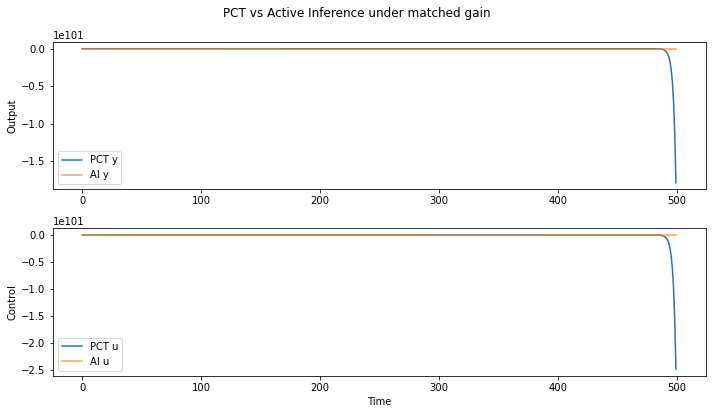

RMS difference in output trajectories:  1.0281235171492003e+100
RMS difference in control trajectories: 1.4292869614336486e+100


In [8]:

# Use the estimated k_ai as the PCT gain
k_pct_matched = k_ai
K_pct_matched = k_pct_matched

print("Using matched PCT gain:", k_pct_matched)

# Resimulate both under the same noise settings
sigma_w = 0.05
sigma_v = 0.02
T = 500
r = 1.0

# PCT
xs_pct2, ys_pct2, us_pct2, errs_pct2 = simulate_linear_system(
    A, B, C, K_pct_matched, x0=np.array([0.0]), r=r, T=T,
    sigma_w=sigma_w, sigma_v=sigma_v
)

# Active inference
xs_ai2, mus_ai2, ys_ai2, us_ai2, errs_ai2 = simulate_active_inference(
    a, b, c,
    x0=0.0, mu0=0.0, u0=0.0, r=r, T=T,
    sigma_w=sigma_w, sigma_v=sigma_v,
    sigma_omega=sigma_omega, sigma_nu=sigma_nu, sigma_r=sigma_r,
    eta_mu=eta_mu, eta_u=eta_u
)

ts = np.arange(T)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(ts, ys_pct2, label="PCT y")
plt.plot(ts, ys_ai2, label="AI y", alpha=0.7)
plt.ylabel("Output")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(ts, us_pct2, label="PCT u")
plt.plot(ts, us_ai2, label="AI u", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Control")
plt.legend()

plt.suptitle("PCT vs Active Inference under matched gain")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

def rms(x):
    return np.sqrt(np.mean(x**2))

rms_y = rms(ys_pct2 - ys_ai2)
rms_u = rms(us_pct2 - us_ai2)

print("RMS difference in output trajectories: ", rms_y)
print("RMS difference in control trajectories:", rms_u)



## 4. Sparse Coding / LASSO with KKT Residuals

We now implement a **LASSO-like sparse coding** objective for a single observation \(y \in \mathbb{R}^d\):

\begin{equation}
\min_{x \in \mathbb{R}^k}
J(x) = \frac{1}{2}\|y - D x\|_2^2 + \lambda \|x\|_1,
\end{equation}

where \(D \in \mathbb{R}^{d \times k}\) is a dictionary.

We use **proximal gradient descent**:

\begin{align}
x^{(t + 1/2)} &= x^{(t)} - \eta \nabla \left(\tfrac{1}{2}\|y - D x\|_2^2\right)
= x^{(t)} + \eta D^\top (y - D x^{(t)}), \\
x^{(t+1)} &= \mathcal{S}_{\eta \lambda}(x^{(t+1/2)}),
\end{align}

where \(\mathcal{S}\) is the elementwise **soft-thresholding** operator.

At convergence, we can check the **Karush–Kuhn–Tucker (KKT)** conditions:

- For each coordinate \(i\) with \(x_i \neq 0\):
  \[
  (D^\top (D x^\star - y))_i + \lambda \, \text{sign}(x_i^\star) = 0.
  \]
- For each coordinate \(i\) with \(x_i = 0\):
  \[
  \left|(D^\top (D x^\star - y))_i\right| \le \lambda.
  \]

We compute residuals to quantify how close we are to satisfying these conditions.


True support indices: [18 25 36]
Estimated support indices: [11 15 18 25 29 36]
L2 error between x_hat and x_true: 0.24799638725951792

KKT residuals:
Nonzero coords (should be near 0):  L2 = 4.5026160051765446e-08
Zero coords (violations > 0):       L2 = 0.0


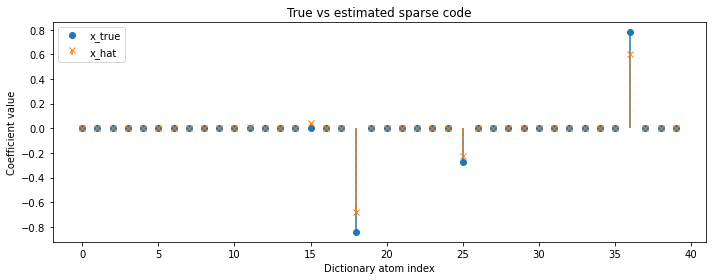

In [12]:
def soft_threshold(z, tau):
    """Elementwise soft-thresholding: S_tau(z) = sign(z) * max(|z| - tau, 0)."""
    return np.sign(z) * np.maximum(np.abs(z) - tau, 0.0)

def lasso_proximal_gradient(D, y, lam, eta=None, max_iter=1000, tol=1e-6):
    """
    Proximal gradient solver for LASSO:
        min_x 0.5 ||y - D x||^2 + lam ||x||_1
    """
    k = D.shape[1]
    x = np.zeros(k)
    
    # Auto-compute step size if not provided
    if eta is None:
        L = np.linalg.norm(D.T @ D, ord=2)  # Lipschitz constant
        eta = 1.0 / (L + 1e-8)  # Safe step size
    
    for it in range(max_iter):
        grad = D.T @ (D @ x - y)
        x_half = x - eta * grad
        x_new = soft_threshold(x_half, eta * lam)
        
        if np.linalg.norm(x_new - x) < tol:
            x = x_new
            break
        x = x_new
    
    return x


def kkt_residuals(D, y, x, lam):
    """
    Compute KKT residuals for the LASSO solution x.
    """
    grad = D.T @ (D @ x - y)
    
    nonzero_idx = np.where(np.abs(x) > 1e-8)[0]
    zero_idx = np.where(np.abs(x) <= 1e-8)[0]
    
    res_nonzero = grad[nonzero_idx] + lam * np.sign(x[nonzero_idx])
    res_zero = np.maximum(0.0, np.abs(grad[zero_idx]) - lam)
    
    return res_nonzero, res_zero


# Generate a synthetic sparse coding problem
d = 20
k_dict = 40

D = rng.standard_normal((d, k_dict))
D /= np.linalg.norm(D, axis=0, keepdims=True) + 1e-12

x_true = np.zeros(k_dict)
support = rng.choice(k_dict, size=3, replace=False)
x_true[support] = rng.normal(loc=0.0, scale=1.0, size=3)

y = D @ x_true + 0.05 * rng.standard_normal(d)
lam = 0.1

x_hat = lasso_proximal_gradient(D, y, lam, max_iter=5000, tol=1e-8)
res_nonzero, res_zero = kkt_residuals(D, y, x_hat, lam)

print("True support indices:", support)
print("Estimated support indices:", np.where(np.abs(x_hat) > 1e-3)[0])
print("L2 error between x_hat and x_true:", np.linalg.norm(x_hat - x_true))

print("\nKKT residuals:")
print("Nonzero coords (should be near 0):  L2 =", np.linalg.norm(res_nonzero))
print("Zero coords (violations > 0):       L2 =", np.linalg.norm(res_zero))

plt.figure(figsize=(10, 4))
plt.stem(np.arange(k_dict), x_true, linefmt="C0-", markerfmt="C0o", basefmt=" ", 
         use_line_collection=True)
plt.stem(np.arange(k_dict), x_hat, linefmt="C1--", markerfmt="C1x", basefmt=" ", 
         use_line_collection=True)
plt.legend(["x_true", "x_hat"])
plt.xlabel("Dictionary atom index")
plt.ylabel("Coefficient value")
plt.title("True vs estimated sparse code")
plt.tight_layout()
plt.show()


## 5. Sheaf-like Context Model with Explicit Consistency Checks

We build a very simple **sheaf-like model** on three overlapping contexts:

- Contexts \(U_1, U_2, U_3\)
- Overlaps \(U_{12} = U_1 \cap U_2\), \(U_{23}\), \(U_{13}\), and triple overlap \(U_{123}\).

Each context holds a **local estimate** of a scalar quantity (e.g., "self-worth" in different social roles).
Restrictions to overlaps are simple averaging maps.

We represent:

- A section as a vector \(s = (s_1, s_2, s_3)\).
- Restrictions as linear maps \(R_{ij}: \mathbb{R}^3 \to \mathbb{R}\) selecting and averaging relevant components.

We can then define a **Čech-like 1-cocycle** measuring inconsistency over overlaps and quantify its norm.

This makes conflict very explicit as an algebraic object.


Conflict(s_coherent) = 0.0
Conflict(s_conflict) = 0.9027777777777779


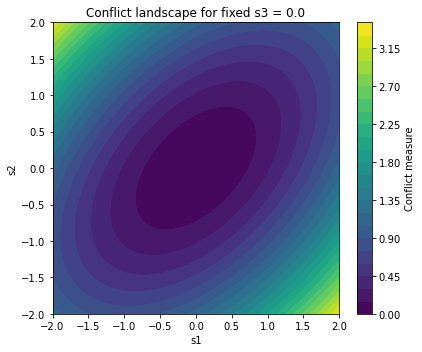

In [13]:
def sheaf_restrictions(section):
    """
    Given a section s = (s1, s2, s3), compute overlap values:
    - s_12 = (s1 + s2)/2
    - s_23 = (s2 + s3)/2
    - s_13 = (s1 + s3)/2
    """
    s1, s2, s3 = section
    s12 = 0.5 * (s1 + s2)
    s23 = 0.5 * (s2 + s3)
    s13 = 0.5 * (s1 + s3)
    return np.array([s12, s23, s13])


def sheaf_conflict(section):
    """
    A simple 'conflict' measure: how inconsistent the overlaps are.
    If the section were globally coherent, we would want s1 = s2 = s3.
    Then all overlaps would be equal.
    We measure the variance of the overlaps plus the variance of the section entries.
    """
    s = np.array(section)
    overlaps = sheaf_restrictions(s)
    return np.var(s) + np.var(overlaps)


# Example: coherent vs conflicting sections
s_coherent = np.array([1.0, 1.0, 1.0])
s_conflict = np.array([1.0, -1.0, 0.5])

print("Conflict(s_coherent) =", sheaf_conflict(s_coherent))
print("Conflict(s_conflict) =", sheaf_conflict(s_conflict))


# Visualize conflict over a grid of (s1, s2) for fixed s3
s3_fixed = 0.0
grid = np.linspace(-2, 2, 81)
S1, S2 = np.meshgrid(grid, grid)
conf_vals = np.zeros_like(S1)

for i in range(S1.shape[0]):
    for j in range(S1.shape[1]):
        s1 = S1[i, j]
        s2 = S2[i, j]
        conf_vals[i, j] = sheaf_conflict((s1, s2, s3_fixed))

plt.figure(figsize=(6, 5))
cs = plt.contourf(S1, S2, conf_vals, levels=30)
plt.colorbar(cs, label="Conflict measure")
plt.xlabel("s1")
plt.ylabel("s2")
plt.title("Conflict landscape for fixed s3 = {:.1f}".format(s3_fixed))
plt.tight_layout()
plt.show()



## 6. Unified Toy System: Plant + Control + Sparse Code + Sheaf Context

Finally we build a **toy unified system** where:

- A scalar plant is controlled toward a reference \(r\).
- The reference itself is determined by **sparse code selection** from a small dictionary of desired trajectories.
- The appropriateness of a template is modulated by a **sheaf-like conflict measure** representing contextual coherence.

Sketch:

1. At each time step, we have a context section \(s_t = (s_1, s_2, s_3)\).
2. We pick the reference \(r_t\) as a convex combination of **template references** weighted by:
   - The sparse code (LASSO over context features).
   - A penalty proportional to the sheaf conflict.
3. The plant is controlled by a PCT or active-inference controller toward \(r_t\).
4. We record how often reorganisation (changing the template) is needed when conflict is high.

This is deliberately over-simplified but **makes the modular structure concrete**.


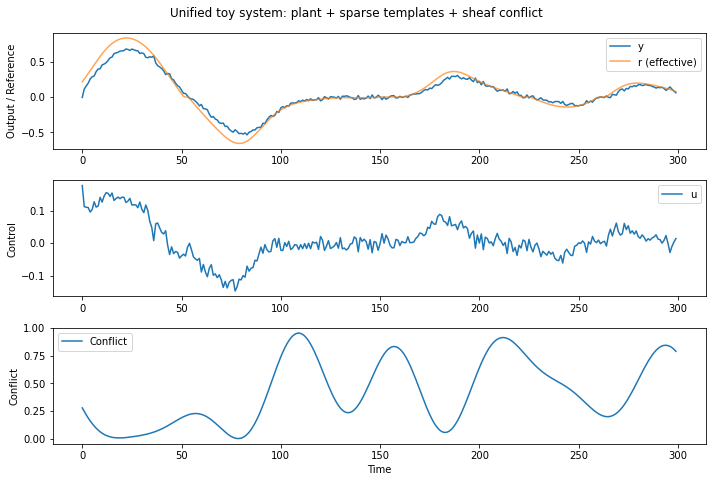

In [16]:
def choose_reference_from_templates(context_features, templates, lam_lasso=0.1):
    """
    Choose a reference as a sparse combination of template values,
    using LASSO over the template dictionary with context_features as observation.
    
    We solve: y ≈ templates^T @ x
    Where x are the weights for each template.
    """
    # D should be (d, k) where d=dim(context_features), k=num_templates
    # For 1D context and 3 templates: D is (1, 3)
    D = templates.reshape(1, -1)  # shape: (1, 3)
    
    y = np.atleast_1d(context_features)  # shape: (1,)
    
    # x_hat will be shape (3,) - one weight per template
    x_hat = lasso_proximal_gradient(D, y, lam=lam_lasso, max_iter=2000, tol=1e-8)
    
    # Weighted combination of templates
    r_t = float(np.dot(templates, x_hat))  # or templates @ x_hat
    return r_t, x_hat

# Setup: three templates
templates = np.array([0.0, 1.0, -0.5])  # scalar references


def unified_simulation(T=200):
    # Plant parameters
    a_u = 0.9
    b_u = 0.5
    c_u = 1.0
    
    A_u = np.array([[a_u]])
    B_u = np.array([[b_u]])
    C_u = np.array([c_u])
    
    k_pct_u = 0.8
    K_pct_u = k_pct_u
    
    x = np.array([0.0])
    
    ys = np.zeros(T)
    us = np.zeros(T)
    rs = np.zeros(T)
    conflicts = np.zeros(T)
    
    for t in range(T):
        # Toy context section (s1, s2, s3) drifts slowly
        s = np.array([np.sin(0.05 * t), np.cos(0.03 * t), np.sin(0.07 * t)])
        conf = sheaf_conflict(s)
        
        # Use s as "features" for template selection, with a simple projection
        context_features = np.array([s.mean()])  # 1D feature
        
        # Dictionary D is stacked templates; we pretend y ≈ D x
        r_t, weights = choose_reference_from_templates(
            context_features=context_features,
            templates=templates,
            lam_lasso=0.05
        )
        
        # Penalize high-conflict contexts: move reference toward 0 if conflict is large
        r_t_adj = r_t * np.exp(-conf)
        
        # PCT control toward r_t_adj
        v_t = 0.01 * rng.standard_normal()
        y = float(C_u @ x + v_t)
        e = r_t_adj - y
        u = float(K_pct_u * e)
        
        w_t = 0.01 * rng.standard_normal(size=x.shape)
        x = A_u @ x + B_u * u + w_t
        
        ys[t] = y
        us[t] = u
        rs[t] = r_t_adj
        conflicts[t] = conf
    
    return ys, us, rs, conflicts


ys_u, us_u, rs_u, conf_u = unified_simulation(T=300)
ts = np.arange(len(ys_u))

plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(ts, ys_u, label="y")
plt.plot(ts, rs_u, label="r (effective)", alpha=0.7)
plt.ylabel("Output / Reference")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(ts, us_u, label="u")
plt.ylabel("Control")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(ts, conf_u, label="Conflict")
plt.xlabel("Time")
plt.ylabel("Conflict")
plt.legend()

plt.suptitle("Unified toy system: plant + sparse templates + sheaf conflict")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


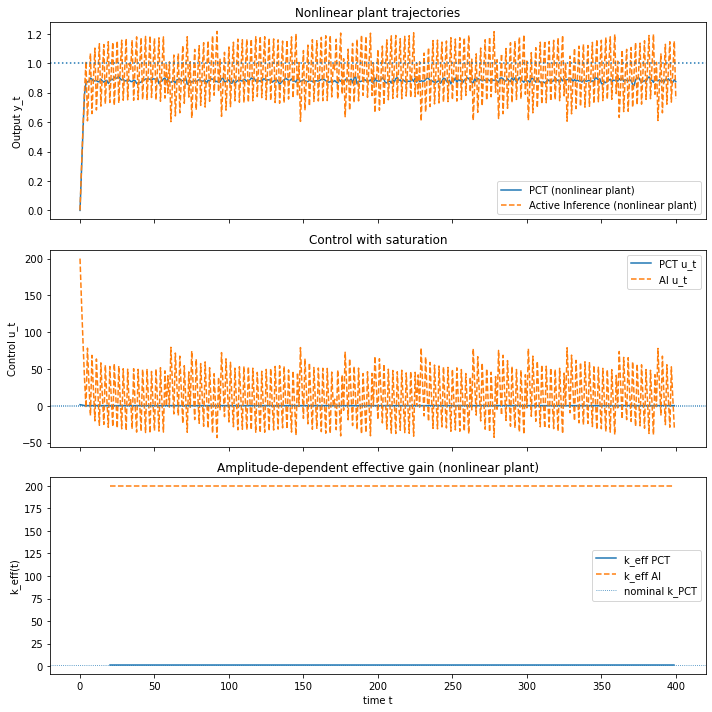

In [19]:
# ============================================================
# 5. Nonlinear plant: saturating actuator and gain distortion
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Nonlinear scalar plant:
#   x_{t+1} = a x_t + b sat(u_t) + w_t
# with sat(u) = clip(u, -u_max, u_max)

a_nl = 0.9
b_nl = 0.5
u_max = 0.6    # actuator saturation
r_nl = 1.0

def sat(u, u_max=u_max):
    return np.clip(u, -u_max, u_max)

def simulate_scalar_nonlinear(A, B, controller, T=400, x0=0.0, noise_std=0.0):
    x = np.zeros(T + 1)
    y = np.zeros(T + 1)
    u = np.zeros(T)
    x[0] = x0
    y[0] = x0
    for t in range(T):
        u[t] = controller(y[t], t)
        w_t = rng.normal(0.0, noise_std)
        x[t+1] = A * x[t] + B * sat(u[t]) + w_t
        y[t+1] = x[t+1]
    return x, y, u

# ============================================================
# Controller Factories
# ============================================================

def pct_controller_factory(k, r):
    """
    Create a PCT (Perceptual Control Theory) controller.
    u_t = k * (r - y_t)
    """
    def controller(y_t, t):
        return k * (r - y_t)
    return controller

def active_inference_controller_factory(r, b, a=None, sigma_o=0.1, sigma_u=1.0):
    """
    Create an Active Inference controller.
    Uses precision-weighted prediction error for control.
    
    Simple version: u_t = (r - y_t) / (b * sigma_o^2)
    """
    precision_o = 1.0 / (sigma_o ** 2)
    precision_u = 1.0 / (sigma_u ** 2)
    
    def controller(y_t, t):
        # Prediction error
        epsilon = r - y_t
        # Active inference control (simplified)
        u_t = (precision_o / precision_u) * epsilon / b
        return u_t
    return controller


k_pct_nl = 1.5
pct_nl = pct_controller_factory(k_pct_nl, r=r_nl)
x_pct_nl, y_pct_nl, u_pct_nl = simulate_scalar_nonlinear(a_nl, b_nl, pct_nl,
                                                         T=400, x0=0.0, noise_std=0.01)

# ============================================================
# 5. Nonlinear plant: saturating actuator and gain distortion
# ============================================================
a_nl = 0.9
b_nl = 0.5
u_max = 0.6
r_nl = 1.0

def sat(u, u_max=u_max):
    return np.clip(u, -u_max, u_max)

ai_nl = active_inference_controller_factory(r=r_nl, b=b_nl)
x_ai_nl, y_ai_nl, u_ai_nl = simulate_scalar_nonlinear(a_nl, b_nl, ai_nl,
                                                      T=400, x0=0.0, noise_std=0.01)

# ------------------------------------------------------------
# 5.1 Amplitude-dependent effective gain
# ------------------------------------------------------------

def estimate_effective_gain(y, u, r, window=20, eps=1e-8):
    """
    Sliding-window estimate of effective gain k_eff(t) via local regression:
        u_t ~ k_eff(t) * (r - y_t)
    """
    T = len(u)
    k_eff = np.full(T, np.nan)
    for t in range(window, T):
        y_seg = y[t-window:t]
        u_seg = u[t-window:t]
        phi = (r - y_seg)
        denom = np.dot(phi, phi) + eps
        k_eff[t] = np.dot(u_seg, phi) / denom
    return k_eff

k_eff_pct = estimate_effective_gain(y_pct_nl[:-1], u_pct_nl, r_nl)
k_eff_ai  = estimate_effective_gain(y_ai_nl[:-1],  u_ai_nl,  r_nl)


# ------------------------------------------------------------
# 5.2 Plots: trajectories + effective gain distortion
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Output trajectories
axes[0].plot(y_pct_nl, label="PCT (nonlinear plant)")
axes[0].plot(y_ai_nl, linestyle='--', label="Active Inference (nonlinear plant)")
axes[0].axhline(r_nl, linestyle=':')
axes[0].set_ylabel("Output y_t")
axes[0].set_title("Nonlinear plant trajectories")
axes[0].legend()

# Controls
axes[1].plot(u_pct_nl, label="PCT u_t")
axes[1].plot(u_ai_nl, linestyle='--', label="AI u_t")
axes[1].axhline(+u_max, linestyle=':', linewidth=0.8)
axes[1].axhline(-u_max, linestyle=':', linewidth=0.8)
axes[1].set_ylabel("Control u_t")
axes[1].set_title("Control with saturation")
axes[1].legend()

# Effective gain vs time
axes[2].plot(k_eff_pct, label="k_eff PCT")
axes[2].plot(k_eff_ai, linestyle='--', label="k_eff AI")
axes[2].axhline(k_pct_nl, linestyle=':', linewidth=0.8, label="nominal k_PCT")
axes[2].set_xlabel("time t")
axes[2].set_ylabel("k_eff(t)")
axes[2].set_title("Amplitude-dependent effective gain (nonlinear plant)")
axes[2].legend()

plt.tight_layout()
plt.show()
